In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("coffee_shop_revenue.csv")

print(df.head())
print(df.info())

   Number_of_Customers_Per_Day  Average_Order_Value  Operating_Hours_Per_Day  \
0                          152                 6.74                       14   
1                          485                 4.50                       12   
2                          398                 9.09                        6   
3                          320                 8.48                       17   
4                          156                 7.44                       17   

   Number_of_Employees  Marketing_Spend_Per_Day  Location_Foot_Traffic  \
0                    4                   106.62                     97   
1                    8                    57.83                    744   
2                    6                    91.76                    636   
3                    4                   462.63                    770   
4                    2                   412.52                    232   

   Daily_Revenue  
0        1547.81  
1        2084.68  
2        3118.39 

In [2]:
X = df.drop("Daily_Revenue", axis=1)   # predictors
y = df["Daily_Revenue"]               # target

print("Predictor Variables:\n", X.columns)
print("Dependent Variable:\n", y.name)

Predictor Variables:
 Index(['Number_of_Customers_Per_Day', 'Average_Order_Value',
       'Operating_Hours_Per_Day', 'Number_of_Employees',
       'Marketing_Spend_Per_Day', 'Location_Foot_Traffic'],
      dtype='object')
Dependent Variable:
 Daily_Revenue


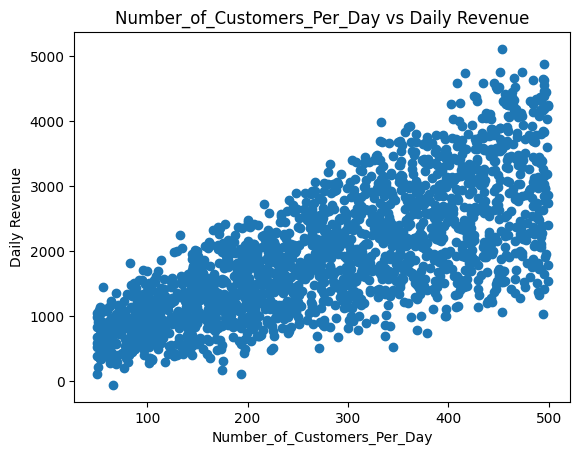

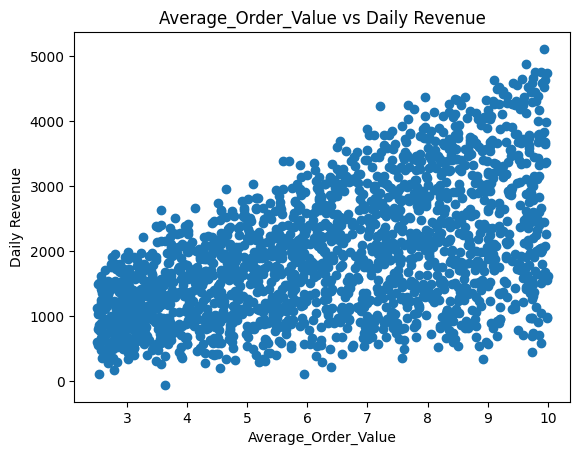

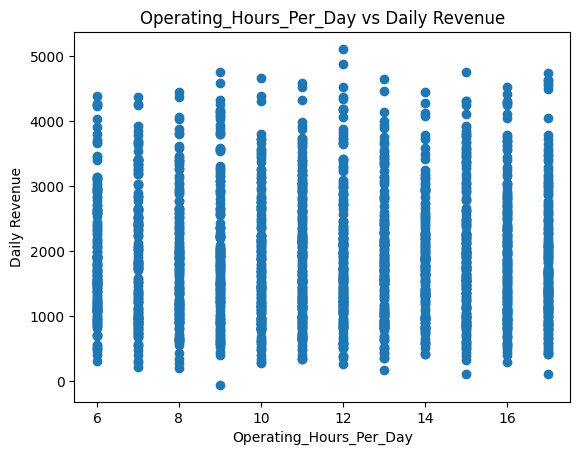

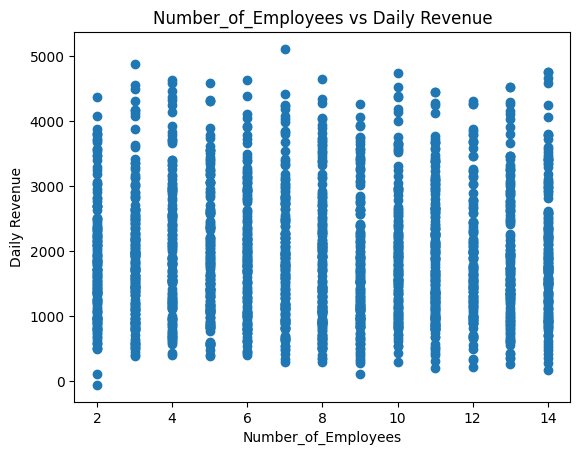

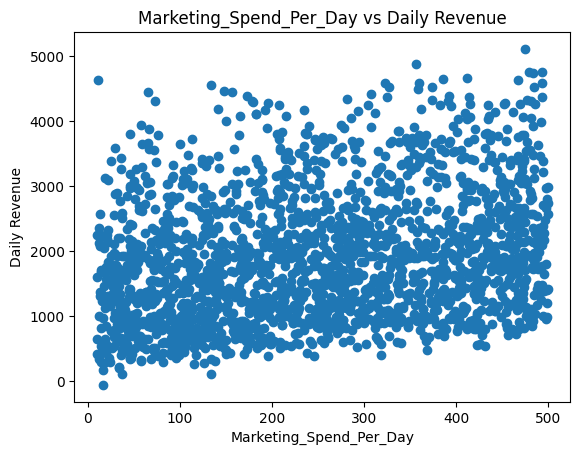

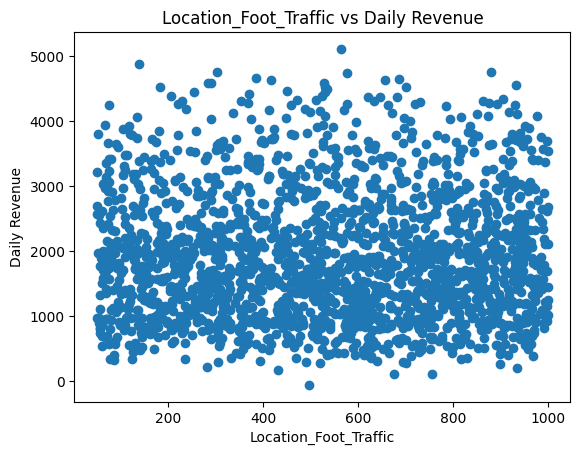

In [3]:
for col in X.columns:
    plt.scatter(df[col], y)
    plt.xlabel(col)
    plt.ylabel("Daily Revenue")
    plt.title(f"{col} vs Daily Revenue")
    plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.linear_model import LinearRegression

model_simple = LinearRegression()

X_train_simple = X_train[["Number_of_Customers_Per_Day"]]
X_test_simple = X_test[["Number_of_Customers_Per_Day"]]

model_simple.fit(X_train_simple, y_train)

y_pred_simple = model_simple.predict(X_test_simple)

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

mse_simple = mean_squared_error(y_test, y_pred_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("Simple Linear Regression:")
print("MSE:", mse_simple)
print("R2 Score:", r2_simple)


Simple Linear Regression:
MSE: 401391.8840212993
R2 Score: 0.5704137785853378


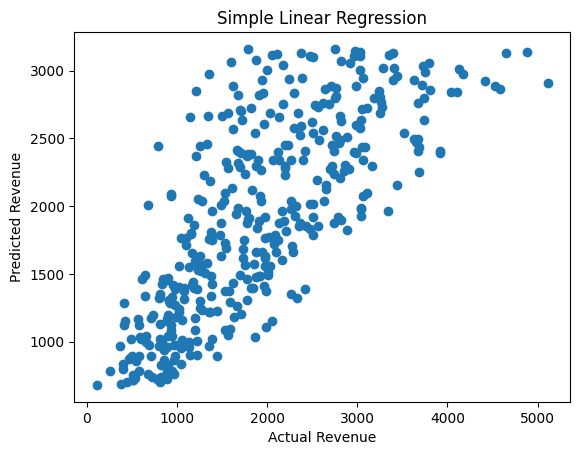

In [8]:
plt.scatter(y_test, y_pred_simple)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Simple Linear Regression")
plt.show()

In [9]:
model_multi = LinearRegression()

model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

In [10]:
mse_multi = mean_squared_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("\nMultiple Linear Regression:")
print("MSE:", mse_multi)
print("R2 Score:", r2_multi)


Multiple Linear Regression:
MSE: 97569.72294013883
R2 Score: 0.8955768408109976


In [11]:
print("\nComparison:")
print("Simple Regression MSE:", mse_simple)
print("Multiple Regression MSE:", mse_multi)


Comparison:
Simple Regression MSE: 401391.8840212993
Multiple Regression MSE: 97569.72294013883
